# Plot the WECC Load Time Series for the WPTO Polar Vortex Case


In [1]:
# Start by importing the packages we need:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import timedelta


## Set the Directory Structure

In [29]:
# Identify the top-level directory and the subdirectory where the data will be stored:
load_data_dir = '/Users/burl878/Documents/Code/code_repos/wpto_polar_vortex_2024_case/data/'
image_output_directory =  '/Users/burl878/Documents/Code/code_repos/wpto_polar_vortex_2024_case/plots/'


## Process and Plot the Total Load Time Series


In [30]:
# Define a function to process aggregate load data and plot the 8760-profile:
def process_and_plot_load_time_series(load_data_dir: str, image_output_directory: str, image_resolution: int, save_images=False):
    
    # Read in the raw data .csv file for scaled data:
    gv_df = pd.read_csv((load_data_dir + 'EIA930_Loads_Scaled_to_2030_ADS_Annual_Energy.csv'))

    # Subset to just hourly demand by BA, drop the index column, and convert the values to floats:
    gv_df = gv_df[1:8761]
    del gv_df["Index"]
    gv_df = gv_df.astype(np.float64)
    
    # Sum the loads across BAs by hour and convert the value from MW to GW:
    gv_df['Total_Load_GW'] = ((gv_df.sum(axis=1)) / 1000).round(2)

    # Reset the index column:
    gv_df = gv_df.reset_index()

    # Rename the time variable:
    gv_df.rename(columns={'index': 'Hour'}, inplace=True)
    
    # Only keep the columns that are needed:
    gv_df = gv_df[['Hour', 'Total_Load_GW']].copy().reset_index(drop=True)

    # Replace the 0 hour with NaN:
    gv_df = gv_df.replace(0, np.nan)

    # Make the plot:
    plt.figure(figsize=(24, 12))
    plt.rcParams['font.size'] = 18
    plt.plot(gv_df['Hour'], gv_df['Total_Load_GW'], color='k', linestyle='-', linewidth=1)
    plt.xlabel('Time [Hours]')
    plt.xlim([0, 8760])
    plt.ylabel('Hourly Total Demand in the Western Interconnection [GW]')
    plt.title('Weather Year 2024 Loads Scaled to 2030-Level Annual Energies')
        
    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_directory + '2024_WY_Load_Time_Series.png'), dpi=image_resolution, bbox_inches='tight')
        
    return gv_df


,Hour,Total_Load_GW
0,1,108.01
1,2,104.81
2,3,102.59
3,4,101.12
4,5,100.06
...,...,...
8755,8756,125.08
8756,8757,126.60
8757,8758,125.01
8758,8759,122.63


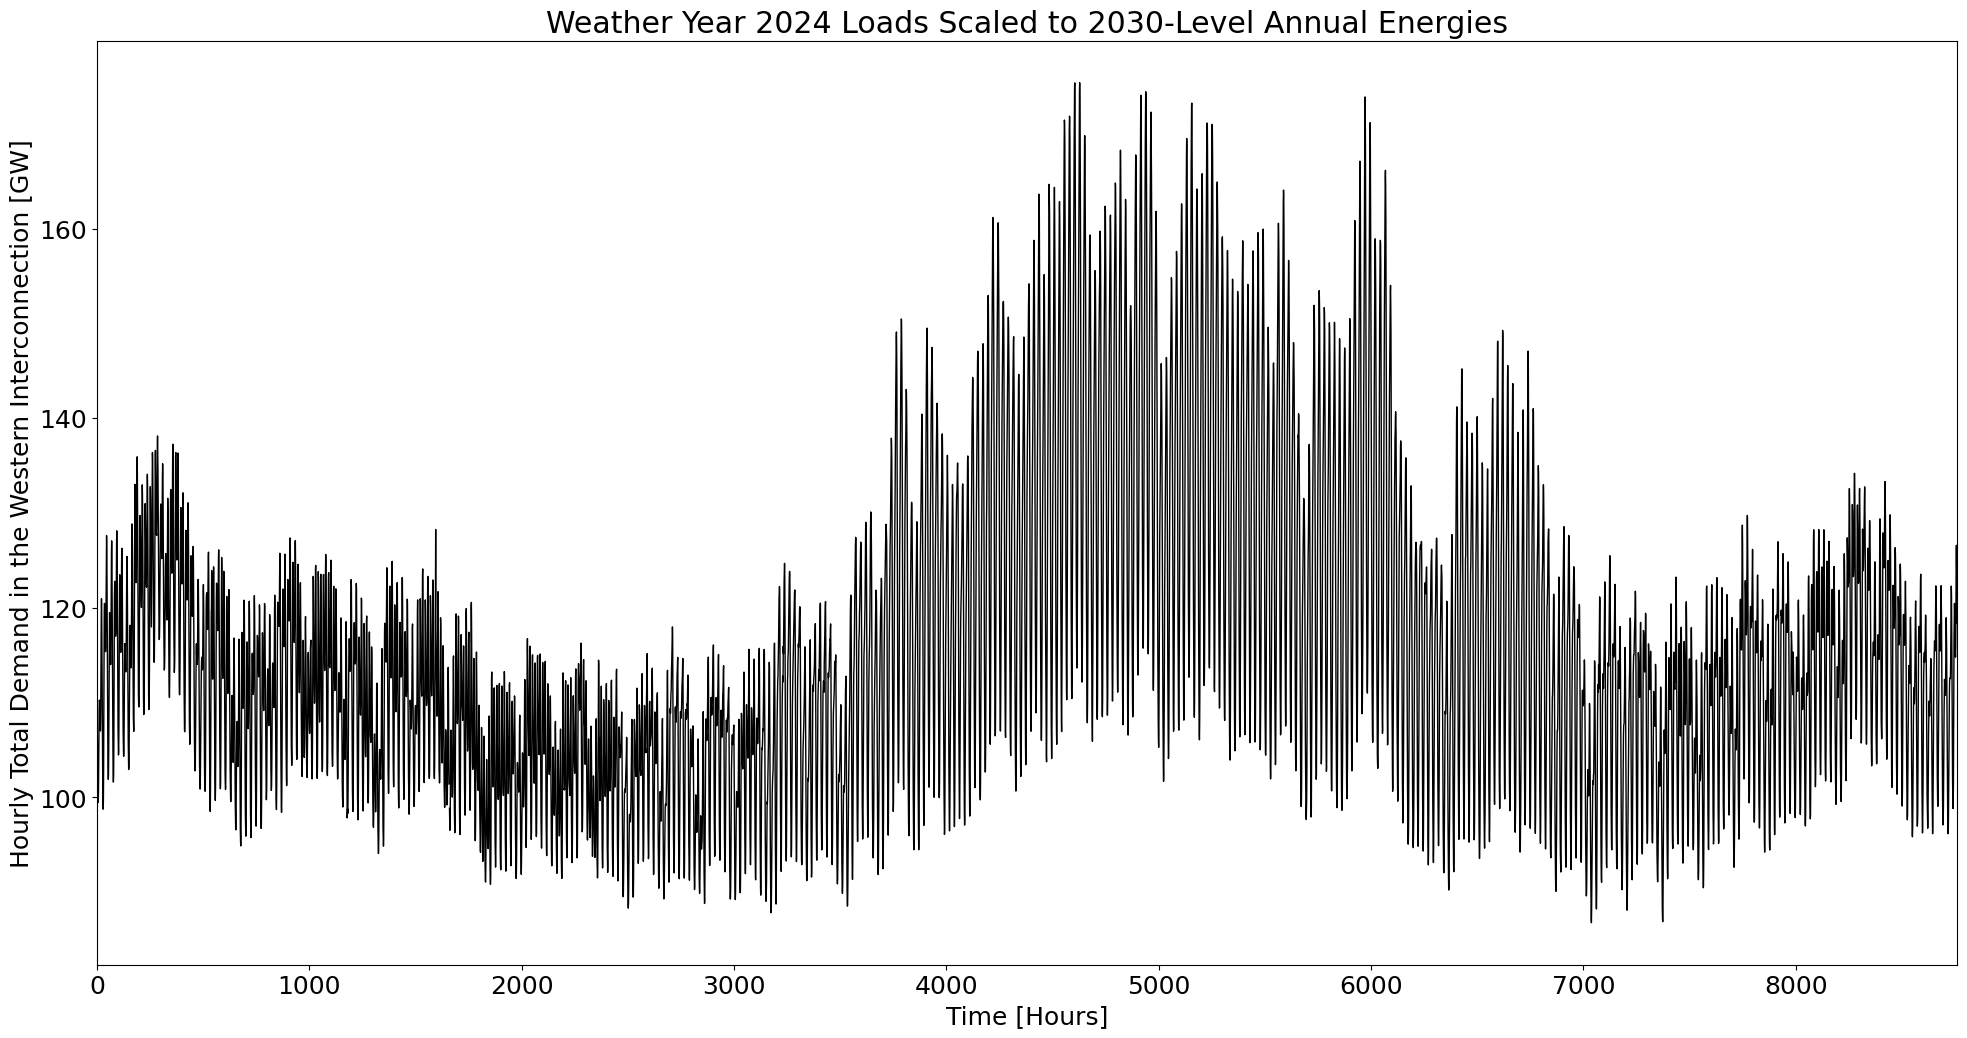

In [31]:
# Test the function:
output_df = process_and_plot_load_time_series(load_data_dir = load_data_dir, 
                                              image_output_directory = image_output_directory,
                                              image_resolution = 300, 
                                              save_images = True)

output_df
